# Modul 2 - Representasi dan Karakteristik Citra Digital
**Mata Kuliah:** Pengolahan Citra dan Visi Komputer  
**Jurusan:** Teknologi Informasi - Politeknik Negeri Malang

## Identitas Mahasiswa
| Keterangan | Isi |
|---|---|
| Nama | Mohammad Al Hafis Hidayatulloh |
| NIM | 254107023005 |

## D. PRAKTIKUM
### D1. Import Library

In [220]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io


### 1. Membaca dan Menampilkan Citra
Gambar KTM dibaca menggunakan `cv2.imread()` lalu ditampilkan. OpenCV menyimpan gambar dalam format **BGR** secara default.

Resolusi gambar: 2870 x 1834


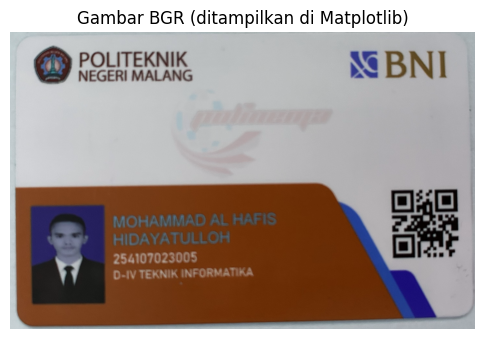

In [221]:
# Membaca foto aktivitas menggunakan OpenCV
gambar = cv2.imread('img/foto_ktm.jpg')

# Menampilkan dimensi gambar
print('Resolusi gambar:', gambar.shape[1], 'x', gambar.shape[0])

# Tampilkan langsung (warna BGR, akan terlihat berbeda di matplotlib)
plt.figure(figsize=(6,4))
plt.imshow(gambar)
plt.title('Gambar BGR (ditampilkan di Matplotlib)')
plt.axis('off')
plt.show()

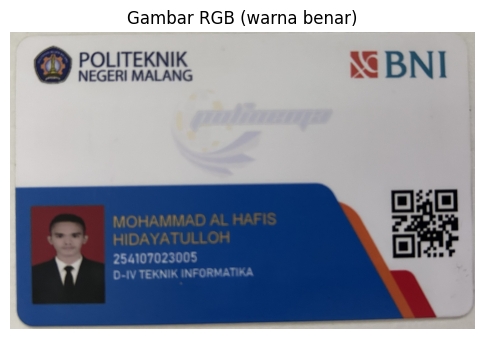

In [222]:
# Konversi channel BGR ke RGB agar warna tampak natural
gambar_rgb = cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(gambar_rgb)
plt.title('Gambar RGB (warna benar)')
plt.axis('off')
plt.show()

### 2. Menampilkan Citra Grayscale
Citra dibaca langsung dalam mode keabuan menggunakan `cv2.IMREAD_GRAYSCALE`.

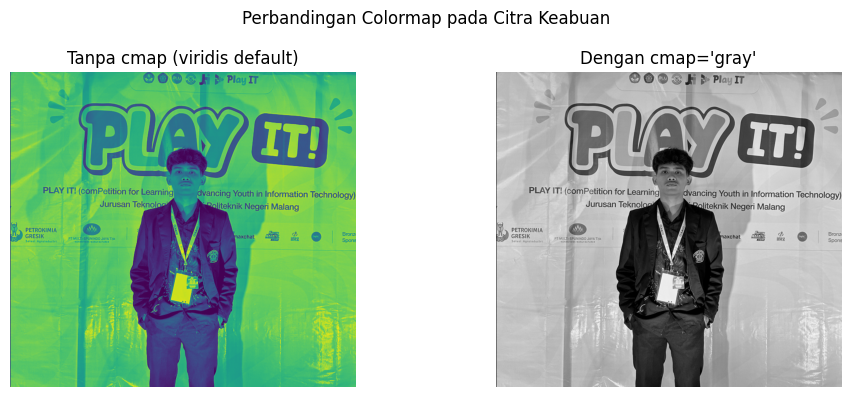

In [223]:
# Membaca gambar langsung sebagai grayscale
gambar_abu = cv2.imread('img/foto_aktivitas.jpg', cv2.IMREAD_GRAYSCALE)

# Bandingkan tampilan tanpa cmap vs dengan cmap='gray'
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(gambar_abu)
ax[0].set_title('Tanpa cmap (viridis default)')
ax[0].axis('off')

ax[1].imshow(gambar_abu, cmap='gray')
ax[1].set_title("Dengan cmap='gray'")
ax[1].axis('off')

plt.suptitle('Perbandingan Colormap pada Citra Keabuan')
plt.tight_layout()
plt.show()

### 3. Mengubah Ukuran Citra (Resizing)
Ukuran citra diperkecil setengahnya menggunakan `cv2.resize()`.

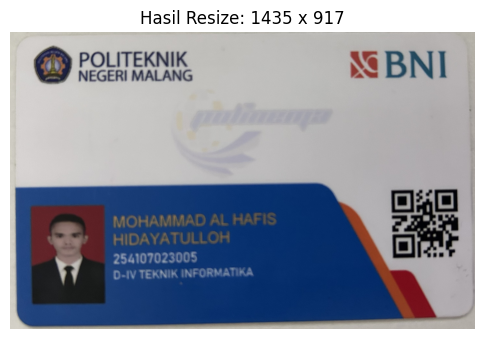

In [224]:
# Konversi ke RGB dulu sebelum resize
gambar_rgb = cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB)

# Hitung ukuran baru: setengah dari ukuran asli
tinggi_asli, lebar_asli = gambar.shape[:2]
lebar_baru  = lebar_asli  // 2
tinggi_baru = tinggi_asli // 2

gambar_kecil = cv2.resize(gambar_rgb, (lebar_baru, tinggi_baru))

plt.figure(figsize=(6, 4))
plt.imshow(gambar_kecil)
plt.title(f'Hasil Resize: {lebar_baru} x {tinggi_baru}')
plt.axis('off')
plt.show()

### 4. Pencerminan Citra (Flipping)
Gambar dicerminkan secara horizontal menggunakan `cv2.flip()`.

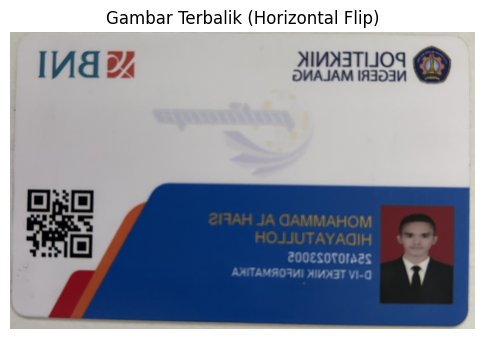

In [225]:
# Flipping horizontal (kiri-kanan)
gambar_flip = cv2.flip(gambar_kecil, 1)

plt.figure(figsize=(6, 4))
plt.imshow(gambar_flip)
plt.title('Gambar Terbalik (Horizontal Flip)')
plt.axis('off')
plt.show()

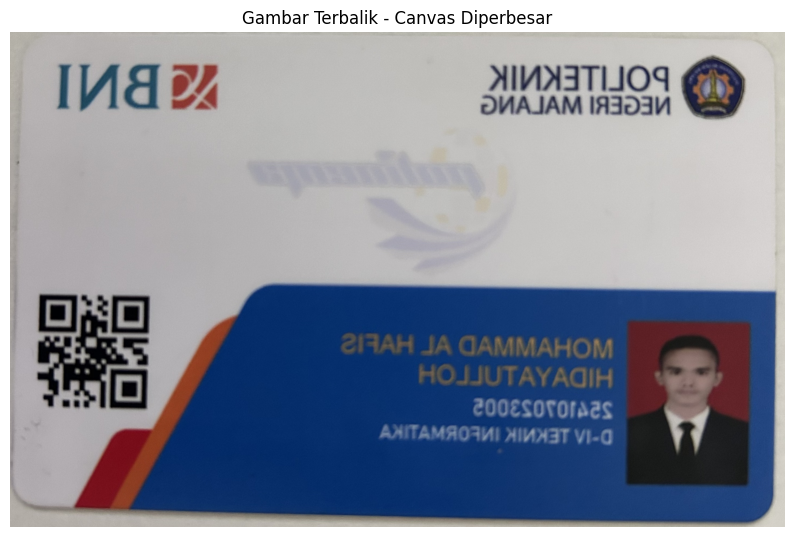

In [226]:
# Flip dengan canvas lebih besar
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(gambar_flip)
ax.set_title('Gambar Terbalik - Canvas Diperbesar')
ax.axis('off')
plt.show()

### 5. Membuat Bentuk Geometri 2D
Kanvas hitam 600x600 dibuat dengan `np.zeros()` bertipe `int16`, kemudian berbagai bentuk geometri ditambahkan.

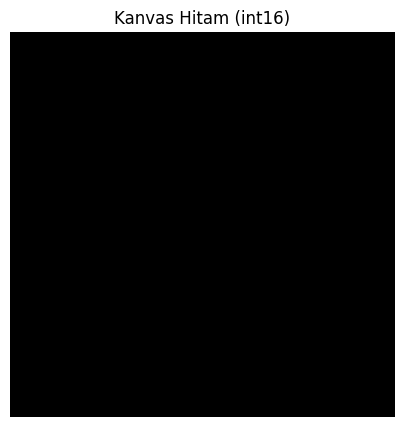

In [227]:
# Buat kanvas hitam 600x600 dengan dtype int16
kanvas = np.zeros(shape=(600, 600, 3), dtype=np.int16)
plt.figure(figsize=(5, 5))
plt.imshow(kanvas)
plt.title('Kanvas Hitam (int16)')
plt.axis('off')
plt.show()

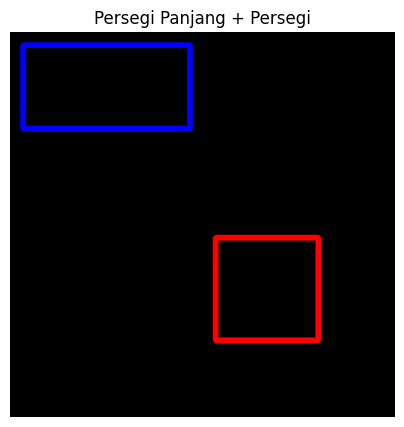

In [228]:
# Menggambar persegi panjang pertama
cv2.rectangle(kanvas, pt1=(20, 20), pt2=(280, 150), color=(0, 0, 255), thickness=8)

# Menggambar persegi (kotak)
cv2.rectangle(kanvas, pt1=(320, 320), pt2=(480, 480), color=(255, 0, 0), thickness=8)

plt.figure(figsize=(5, 5))
plt.imshow(kanvas)
plt.title('Persegi Panjang + Persegi')
plt.axis('off')
plt.show()

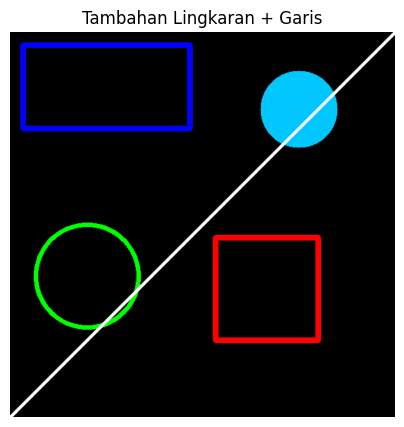

In [229]:
# Lingkaran tanpa isian
cv2.circle(kanvas, center=(120, 380), radius=80, color=(0, 255, 0), thickness=6)

# Lingkaran penuh (isian)
cv2.circle(kanvas, center=(450, 120), radius=60, color=(0, 200, 255), thickness=-1)

# Garis diagonal
cv2.line(kanvas, pt1=(0, 600), pt2=(600, 0), color=(255, 255, 255), thickness=4)

plt.figure(figsize=(5, 5))
plt.imshow(kanvas)
plt.title('Tambahan Lingkaran + Garis')
plt.axis('off')
plt.show()

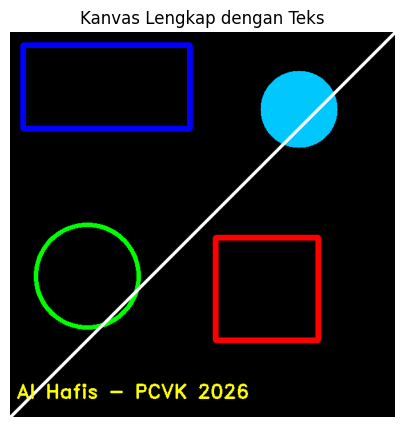

In [230]:
# Menambahkan teks nama
font = cv2.FONT_HERSHEY_DUPLEX
cv2.putText(kanvas, text='Al Hafis - PCVK 2026',
            org=(10, 570), fontFace=font, fontScale=1.0,
            color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)

plt.figure(figsize=(5, 5))
plt.imshow(kanvas)
plt.title('Kanvas Lengkap dengan Teks')
plt.axis('off')
plt.show()

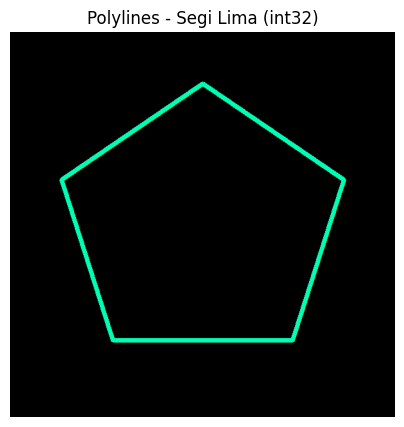

In [231]:
# Kanvas kedua int32 untuk polylines
kanvas2 = np.zeros(shape=(600, 600, 3), dtype=np.int32)

# Titik-titik segi lima
titik = np.array(
    [[300, 80], [520, 230], [440, 480], [160, 480], [80, 230]],
    dtype=np.int32
)
pts = titik.reshape((-1, 1, 2))

cv2.polylines(kanvas2, [pts], isClosed=True, color=(0, 255, 180), thickness=5)

plt.figure(figsize=(5, 5))
plt.imshow(kanvas2)
plt.title('Polylines - Segi Lima (int32)')
plt.axis('off')
plt.show()

## PERTANYAAN PRAKTIKUM

### Pertanyaan 1

Nilai piksel [0,0] format cv2 (BGR): [190 202 204]


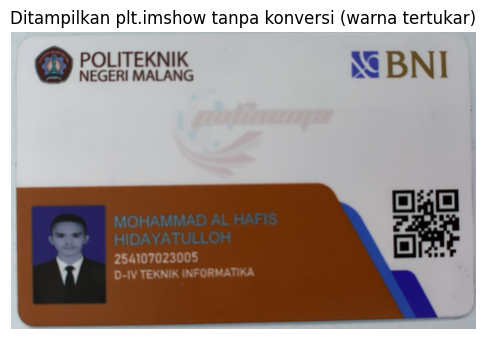

In [232]:
# Membaca dengan dua cara berbeda
gambar_cv2 = cv2.imread('img/foto_ktm.jpg')   # BGR

# Nilai piksel [0,0] dari cv2 (format BGR)
print('Nilai piksel [0,0] format cv2 (BGR):', gambar_cv2[0, 0])

# Tampilkan langsung tanpa konversi (warna tertukar)
plt.figure(figsize=(6, 4))
plt.imshow(gambar_cv2)
plt.title('Ditampilkan plt.imshow tanpa konversi (warna tertukar)')
plt.axis('off')
plt.show()

**Jawaban:**  
Hasilnya berbeda karena `cv2.imread()` membaca gambar dalam urutan kanal **BGR** (Blue-Green-Red), sedangkan `plt.imshow()` mengasumsikan urutan **RGB**. Akibatnya kanal merah dan biru tertukar saat ditampilkan. Nilai piksel [0,0] pada format BGR menunjukkan urutan [B, G, R], bukan [R, G, B] seperti yang diasumsikan oleh Matplotlib.

### Pertanyaan 2

In [233]:
# Kanvas hitam int16 dan int32 dengan ukuran sama
img_16 = np.zeros((600, 600, 3), dtype=np.int16)
img_32 = np.zeros((600, 600, 3), dtype=np.int32)

print('Tipe data img_16 :', img_16.dtype)
print('Min img_16        :', img_16.min(), '| Max:', img_16.max())
print('Total byte memori :', img_16.nbytes)
print('-' * 35)
print('Tipe data img_32 :', img_32.dtype)
print('Min img_32        :', img_32.min(), '| Max:', img_32.max())
print('Total byte memori :', img_32.nbytes)
print()
print('Rasio memori int32/int16:', img_32.nbytes // img_16.nbytes)

Tipe data img_16 : int16
Min img_16        : 0 | Max: 0
Total byte memori : 2160000
-----------------------------------
Tipe data img_32 : int32
Min img_32        : 0 | Max: 0
Total byte memori : 4320000

Rasio memori int32/int16: 2


**Jawaban:**  
Tampilan **identik** karena semua piksel bernilai 0 (hitam).  
Ukuran memori **berbeda**: `int16` menggunakan 2 byte/elemen, `int32` 4 byte/elemen, sehingga `int32` membutuhkan memori **2x lebih besar** dari `int16` untuk jumlah piksel yang sama.

### Pertanyaan 3

**Jawaban:**  
Fungsi `cv2.imshow()` membutuhkan GUI (Graphical User Interface) seperti Qt/GTK untuk membuka jendela tampilan. Google Colab berjalan di server cloud Linux tanpa antarmuka grafis (*headless*), sehingga tidak ada display server yang tersedia dan `cv2.imshow()` akan error atau hang.  

`cv2_imshow` dari `google.colab.patches` mengakali hal ini dengan mengonversi array gambar menjadi PNG lalu ditampilkan sebagai output sel melalui IPython display, tanpa memerlukan GUI sama sekali.

### Pertanyaan 4

Nilai piksel asli skimage [0,0]         : [33 29 43]
Nilai piksel setelah konversi BGR->RGB  : [43 29 33]


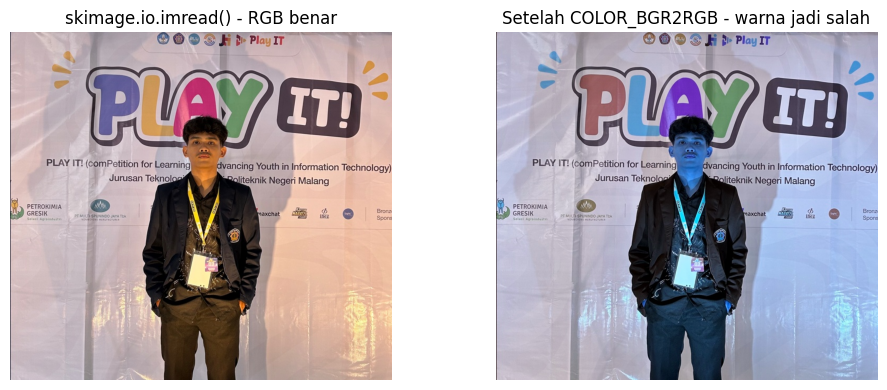

In [234]:
from skimage import io as skio

# Baca dengan skimage (hasilnya RGB)
gambar_skimage = skio.imread('img/foto_aktivitas.jpg')

# Terapkan konversi BGR->RGB pada gambar skimage (seharusnya tidak perlu)
gambar_salah = cv2.cvtColor(gambar_skimage, cv2.COLOR_BGR2RGB)

print('Nilai piksel asli skimage [0,0]         :', gambar_skimage[0, 0])
print('Nilai piksel setelah konversi BGR->RGB  :', gambar_salah[0, 0])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(gambar_skimage)
ax[0].set_title('skimage.io.imread() - RGB benar')
ax[0].axis('off')
ax[1].imshow(gambar_salah)
ax[1].set_title('Setelah COLOR_BGR2RGB - warna jadi salah')
ax[1].axis('off')
plt.tight_layout()
plt.show()

**Jawaban:**  
Warna sebenarnya ditampilkan oleh **`skimage.io.imread()`** karena langsung menghasilkan format RGB yang benar untuk `plt.imshow()`.  

Menerapkan `COLOR_BGR2RGB` pada hasil skimage justru membalikkan urutan kanal yang semula sudah benar (RGB → BGR), sehingga warna menjadi tidak natural. Terbukti dari nilai piksel yang posisi channel-nya berbalik antara kedua gambar.

### Pertanyaan 5

Shape sebelum figsize besar: (1834, 2870, 3)


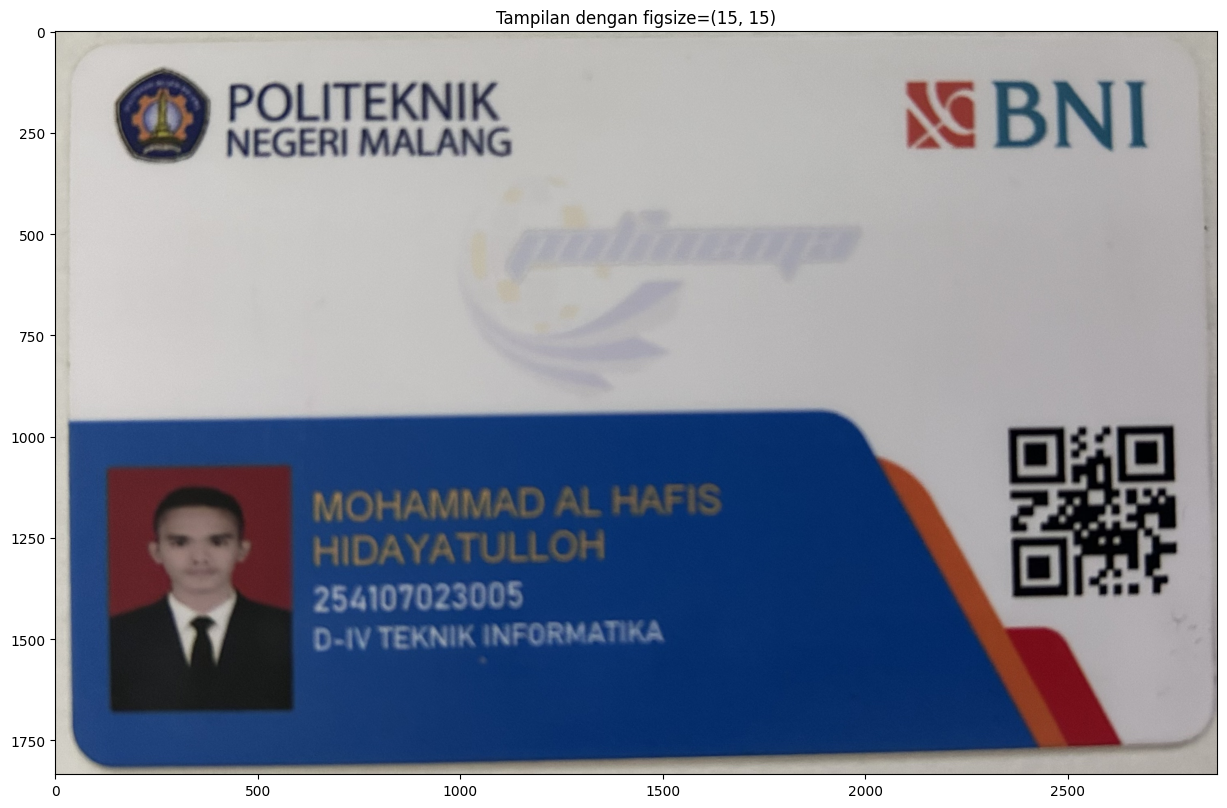

Shape sesudah figsize besar: (1834, 2870, 3)

Kesimpulan: figsize hanya mengubah ukuran tampilan di layar,
bukan mengubah data piksel. img.shape tidak berubah sama sekali.


In [235]:
# Bentuk sebelum tampil figsize besar
print('Shape sebelum figsize besar:', gambar.shape)

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
plt.title('Tampilan dengan figsize=(15, 15)')
plt.show()

print('Shape sesudah figsize besar:', gambar.shape)
print()
print('Kesimpulan: figsize hanya mengubah ukuran tampilan di layar,')
print('bukan mengubah data piksel. img.shape tidak berubah sama sekali.')

**Jawaban:**  
Nilai `img.shape` **tidak berubah** meskipun `figsize` diperbesar.  

`figsize` hanya mengatur ukuran canvas tampilan Matplotlib dalam satuan inci, tidak menyentuh data piksel sama sekali. Hanya `cv2.resize()` yang benar-benar mengubah jumlah piksel dan dimensi array.

## TUGAS PRAKTIKUM - Penerapan

### Tugas 1 - Visualisasi Kombinasi Kanal Warna

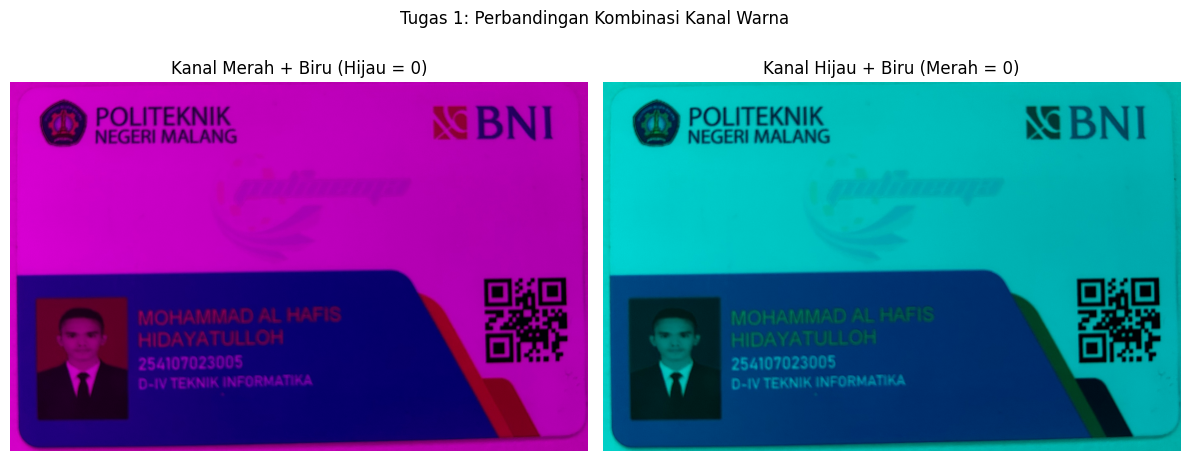

In [236]:
# Gambar dalam format BGR
gambar_bgr = cv2.imread('img/foto_ktm.jpg')

# Kombinasi Merah-Biru (nonaktifkan channel Hijau, indeks 1 dalam BGR)
gambar_rb = gambar_bgr.copy()
gambar_rb[:, :, 1] = 0

# Kombinasi Hijau-Biru (nonaktifkan channel Merah, indeks 2 dalam BGR)
gambar_gb = gambar_bgr.copy()
gambar_gb[:, :, 2] = 0

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(gambar_rb, cv2.COLOR_BGR2RGB))
ax[0].set_title('Kanal Merah + Biru (Hijau = 0)')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gambar_gb, cv2.COLOR_BGR2RGB))
ax[1].set_title('Kanal Hijau + Biru (Merah = 0)')
ax[1].axis('off')
plt.suptitle('Tugas 1: Perbandingan Kombinasi Kanal Warna')
plt.tight_layout()
plt.show()

### Tugas 2 - Tiga Bentuk Pencerminan

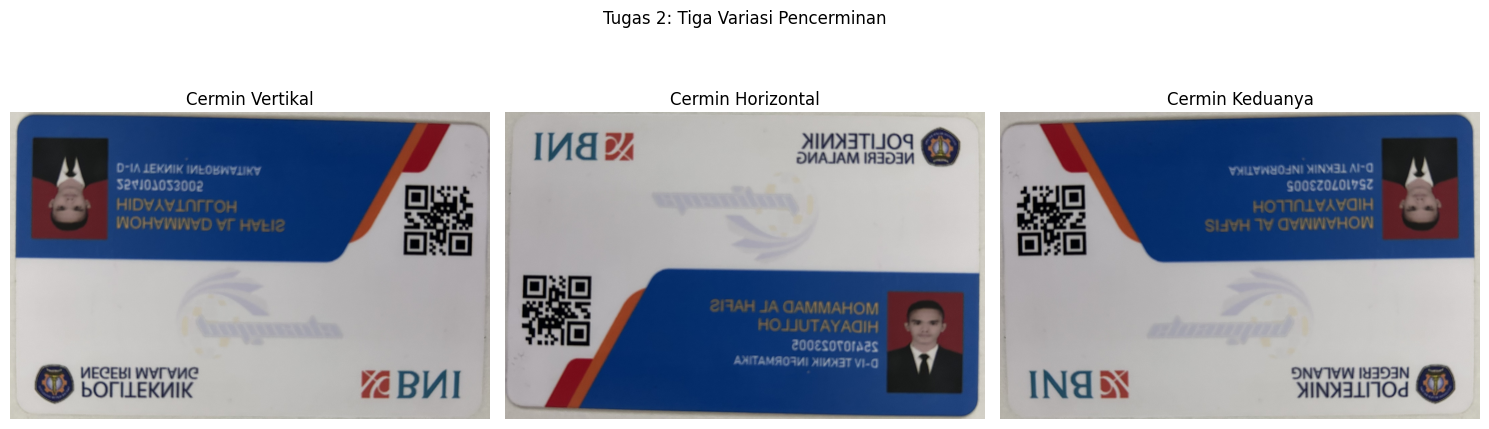

In [237]:
flip_vertikal    = cv2.flip(gambar_bgr, 0)
flip_horizontal  = cv2.flip(gambar_bgr, 1)
flip_keduanya    = cv2.flip(gambar_bgr, -1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for sb, gb, jd in zip(
    ax,
    [flip_vertikal, flip_horizontal, flip_keduanya],
    ['Cermin Vertikal', 'Cermin Horizontal', 'Cermin Keduanya']
):
    sb.imshow(cv2.cvtColor(gb, cv2.COLOR_BGR2RGB))
    sb.set_title(jd)
    sb.axis('off')

plt.suptitle('Tugas 2: Tiga Variasi Pencerminan')
plt.tight_layout()
plt.show()

### Tugas 3 - Anotasi Geometri pada Foto Aktivitas

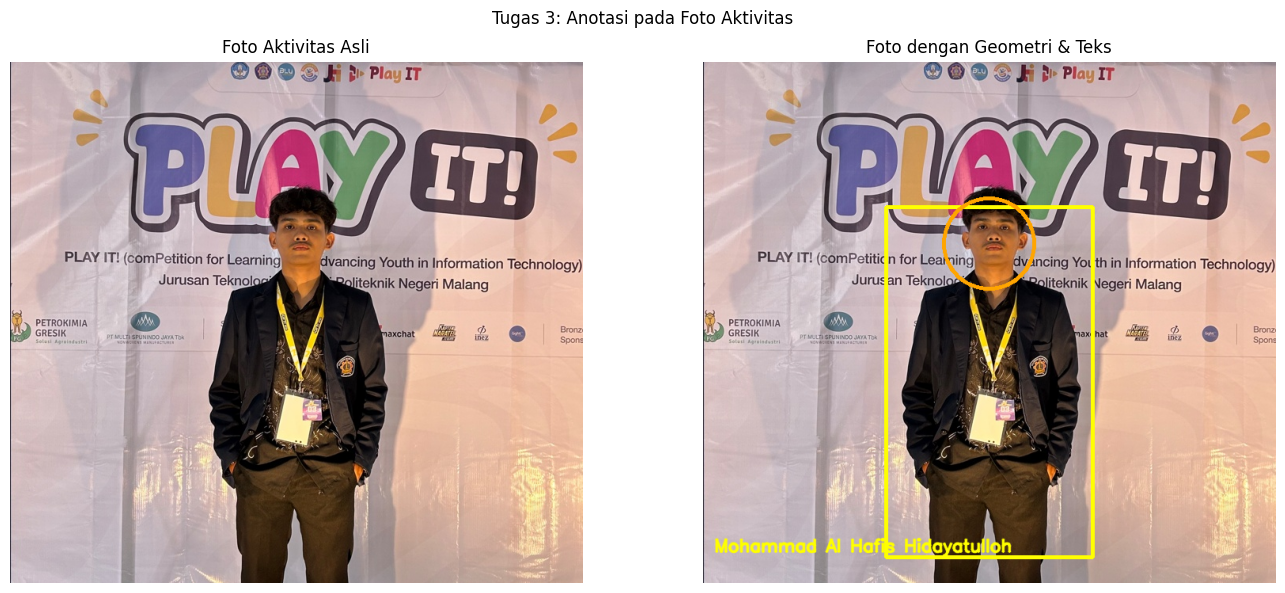

In [238]:
# Load foto aktivitas secara eksplisit (bukan KTM)
gambar_bgr_aktv = cv2.imread('img/foto_aktivitas.jpg')
gambar_anotasi  = gambar_bgr_aktv.copy()
h_g, w_g = gambar_anotasi.shape[:2]

# Koordinat proporsional disesuaikan dengan posisi badan dan wajah di foto PLAY IT
x1 = int(w_g * 0.32)
y1 = int(h_g * 0.28)
x2 = int(w_g * 0.68)
y2 = int(h_g * 0.95)

# Rectangle di area badan
cv2.rectangle(gambar_anotasi, pt1=(x1, y1), pt2=(x2, y2),
              color=(0, 255, 255), thickness=4)

# Circle di area kepala
cx = (x1 + x2) // 2
cy = int(h_g * 0.35)
radius = int(w_g * 0.08)
cv2.circle(gambar_anotasi, center=(cx, cy), radius=radius,
           color=(0, 165, 255), thickness=3)

# Teks nama
skala = max(0.5, w_g / 1000)
cv2.putText(
    gambar_anotasi,
    text='Mohammad Al Hafis Hidayatulloh',
    org=(int(w_g * 0.02), int(h_g * 0.94)),
    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
    fontScale=skala,
    color=(0, 255, 255),
    thickness=2,
    lineType=cv2.LINE_AA
)

# Tampilkan perbandingan asli vs teranotasi
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(cv2.cvtColor(gambar_bgr_aktv, cv2.COLOR_BGR2RGB))
ax[0].set_title('Foto Aktivitas Asli')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gambar_anotasi, cv2.COLOR_BGR2RGB))
ax[1].set_title('Foto dengan Geometri & Teks')
ax[1].axis('off')
plt.suptitle('Tugas 3: Anotasi pada Foto Aktivitas')
plt.tight_layout()
plt.show()

## TUGAS PRAKTIKUM - Analisa

**Pertanyaan:** Apakah proses pencerminan (flip) mengubah dimensi piksel dan ukuran memori dari gambar tersebut?

**Hipotesis:** Karena flip hanya memindahkan posisi piksel tanpa menambah atau menghapus data, dimensi dan ukuran memori seharusnya tetap sama.

In [239]:
gambar_asli = cv2.imread('img/foto_ktm.jpg')
gambar_cermin = cv2.flip(gambar_asli, 1)

print('=== SEBELUM DICERMINKAN ===')
print('Dimensi (Shape)      :', gambar_asli.shape)
print('Ukuran Memori (bytes):', gambar_asli.nbytes)

print('\n=== SESUDAH DICERMINKAN ===')
print('Dimensi (Shape)      :', gambar_cermin.shape)
print('Ukuran Memori (bytes):', gambar_cermin.nbytes)

print('\nDimensi sama  :', gambar_asli.shape == gambar_cermin.shape)
print('Memori sama   :', gambar_asli.nbytes == gambar_cermin.nbytes)

=== SEBELUM DICERMINKAN ===
Dimensi (Shape)      : (1834, 2870, 3)
Ukuran Memori (bytes): 15790740

=== SESUDAH DICERMINKAN ===
Dimensi (Shape)      : (1834, 2870, 3)
Ukuran Memori (bytes): 15790740

Dimensi sama  : True
Memori sama   : True


**Kesimpulan:**  
Proses pencerminan **tidak mengubah** dimensi piksel maupun ukuran memori. Hal ini karena `cv2.flip()` hanya menyusun ulang posisi piksel (membalik urutan baris atau kolom), tanpa menambah atau menghapus data apapun. Jumlah piksel tetap sama sehingga memori yang dibutuhkan juga sama persis.

## TUGAS PRAKTIKUM - Aplikasi

### Studi Kasus 1 - Label Identitas Adaptif
Fungsi berikut membubuhkan label identitas di bawah foto secara proporsional terhadap ukuran gambar masukan.

Foto 1 asli: (659, 724) -> berlabel: (713, 724)
Foto 2 asli: (1834, 2870) -> berlabel: (1986, 2870)


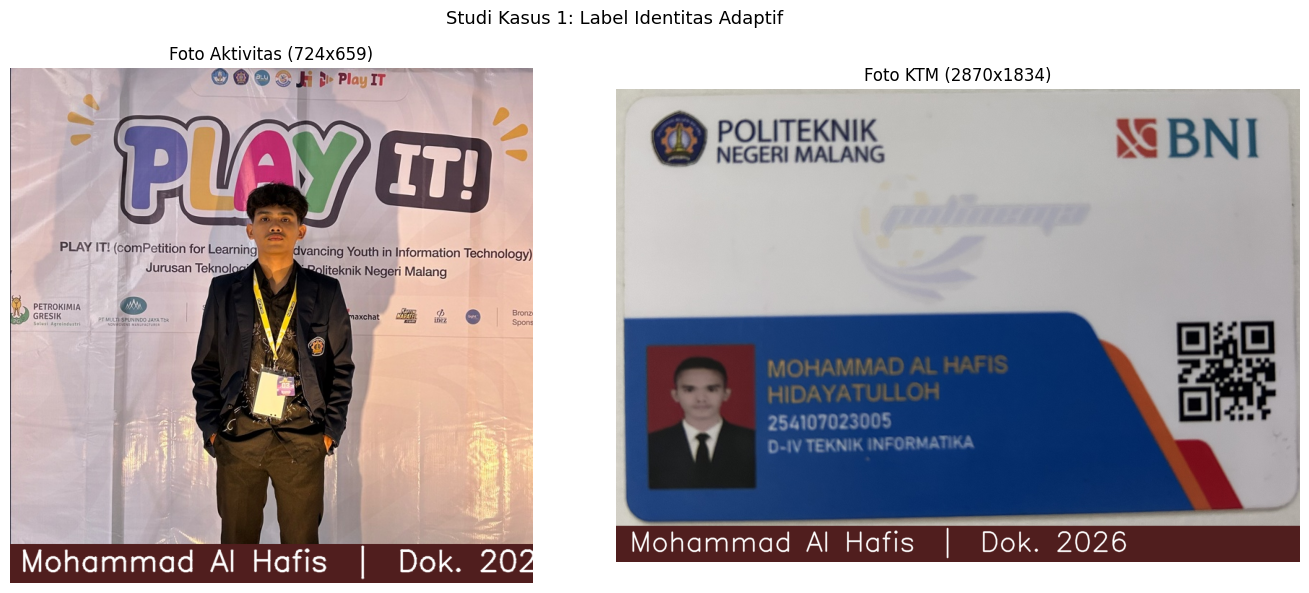

In [240]:
def tambah_label_identitas(gambar_bgr, nama, tahun):
    """Menambahkan bar label di bawah gambar secara adaptif."""
    h, w = gambar_bgr.shape[:2]
    tinggi_bar = max(30, h // 12)       # 1/12 tinggi, minimal 30px
    hasil = np.zeros((h + tinggi_bar, w, 3), dtype=np.uint8)
    hasil[0:h, :] = gambar_bgr
    hasil[h:, :]  = (30, 30, 80)        # warna bar: biru gelap

    skala  = tinggi_bar / 40.0
    tebal  = max(1, int(skala * 1.5))
    teks   = f'{nama}  |  Dok. {tahun}'
    posisi = (int(w * 0.02), h + int(tinggi_bar * 0.70))

    cv2.putText(hasil, teks, posisi,
                cv2.FONT_HERSHEY_SIMPLEX, skala,
                (255, 255, 255), tebal, cv2.LINE_AA)
    return hasil


# Terapkan pada dua foto berbeda ukuran
foto1 = cv2.imread('img/foto_aktivitas.jpg')  # foto aktivitas (ada wajah)
foto2 = cv2.imread('img/foto_ktm.jpg')         # foto KTM

hasil1 = tambah_label_identitas(foto1, 'Mohammad Al Hafis', '2026')
hasil2 = tambah_label_identitas(foto2, 'Mohammad Al Hafis', '2026')

print(f'Foto 1 asli: {foto1.shape[:2]} -> berlabel: {hasil1.shape[:2]}')
print(f'Foto 2 asli: {foto2.shape[:2]} -> berlabel: {hasil2.shape[:2]}')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(cv2.cvtColor(hasil1, cv2.COLOR_BGR2RGB))
ax[0].set_title(f'Foto Aktivitas ({foto1.shape[1]}x{foto1.shape[0]})')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(hasil2, cv2.COLOR_BGR2RGB))
ax[1].set_title(f'Foto KTM ({foto2.shape[1]}x{foto2.shape[0]})')
ax[1].axis('off')
plt.suptitle('Studi Kasus 1: Label Identitas Adaptif', fontsize=13)
plt.tight_layout()
plt.show()

### Studi Kasus 2 - Thumbnail Persegi 1:1
Mengubah foto menjadi thumbnail persegi tanpa mengubah rasio asli dengan menambahkan padding berwarna, lalu sisipkan nama toko.

Orientasi foto_potret  : lanskap
Orientasi foto_lanskap : lanskap
Shape thumbnail potret : (724, 724)
Shape thumbnail lanskap: (900, 900)


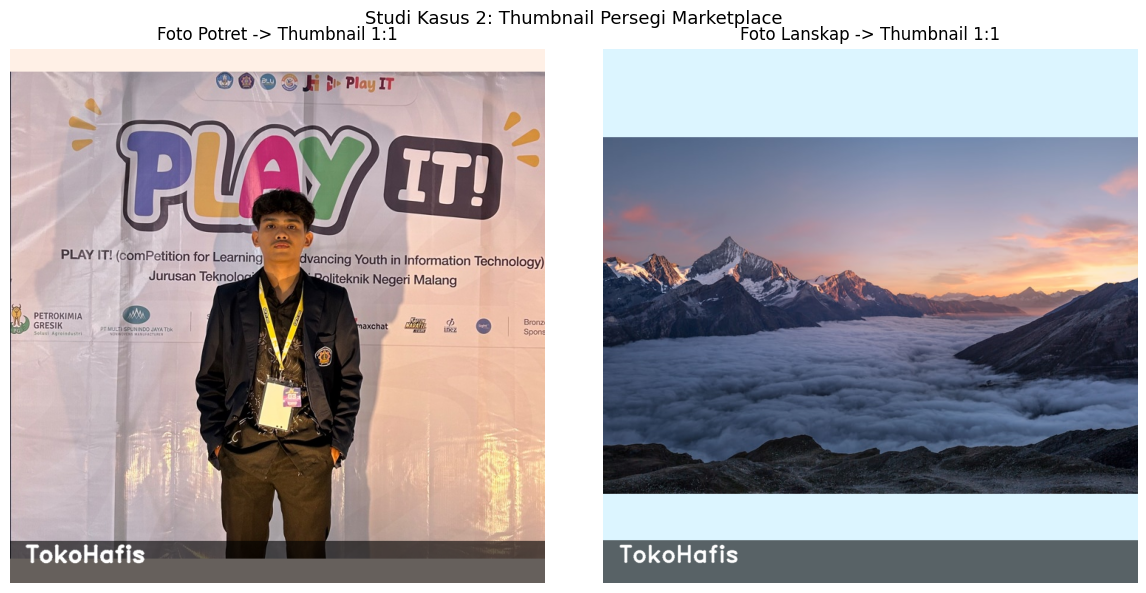

In [241]:
def buat_thumbnail(gambar_bgr, warna_bg=(220, 220, 220), nama_toko='Toko'):
    """Buat thumbnail persegi dari gambar apa pun dengan padding."""
    h, w = gambar_bgr.shape[:2]
    sisi      = max(h, w)
    thumbnail = np.full((sisi, sisi, 3), warna_bg, dtype=np.uint8)

    # Tempatkan gambar di tengah
    dy = (sisi - h) // 2
    dx = (sisi - w) // 2
    thumbnail[dy:dy+h, dx:dx+w] = gambar_bgr

    # Strip gelap bawah untuk watermark
    strip = int(sisi * 0.08)
    thumbnail[sisi-strip:, :] = (thumbnail[sisi-strip:, :] * 0.4).astype(np.uint8)

    # Nama toko
    skala_wm = sisi / 700.0
    tebal_wm = max(1, int(skala_wm * 2))
    cv2.putText(thumbnail, nama_toko,
                (int(sisi * 0.03), int(sisi * 0.96)),
                cv2.FONT_HERSHEY_DUPLEX,
                skala_wm, (255, 255, 255), tebal_wm, cv2.LINE_AA)
    return thumbnail


# Uji pada dua foto berbeda orientasi
foto_potret  = cv2.imread('img/foto_aktivitas.jpg')   # potret
foto_lanskap = cv2.imread('img/foto_bebas1.jpg')   # lanskap

thumb_p = buat_thumbnail(foto_potret,  (230, 240, 255), 'TokoHafis')
thumb_l = buat_thumbnail(foto_lanskap, (255, 245, 220), 'TokoHafis')

print('Orientasi foto_potret  :', 'potret'  if foto_potret.shape[0]  > foto_potret.shape[1]  else 'lanskap')
print('Orientasi foto_lanskap :', 'lanskap' if foto_lanskap.shape[1] > foto_lanskap.shape[0] else 'potret')
print('Shape thumbnail potret :', thumb_p.shape[:2])
print('Shape thumbnail lanskap:', thumb_l.shape[:2])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(thumb_p, cv2.COLOR_BGR2RGB))
ax[0].set_title('Foto Potret -> Thumbnail 1:1')
ax[0].set_aspect('equal')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(thumb_l, cv2.COLOR_BGR2RGB))
ax[1].set_title('Foto Lanskap -> Thumbnail 1:1')
ax[1].set_aspect('equal')
ax[1].axis('off')
plt.suptitle('Studi Kasus 2: Thumbnail Persegi Marketplace', fontsize=13)
plt.tight_layout()
plt.show()